In [2]:
from torch import optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.models as models
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

# Resizing data to 256 , and random cropping 224X224 improves performance as Resnet and VGG Models are built with that expectation and trained such .
#As this is transfer learning that size and crop works best . 
#Random Horizontal Flip introduced for better training . Normalized data to Imagenet Mean and Standard Deviation
# Batch size 32 for Resnet models are they are faster and less complex and training time is manageable .
#Batch Size 64 for VGG19 as its more complex model with very high training time . 

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transformer = transforms.Compose([
transforms.Resize(256),
transforms.RandomCrop(224),
transforms.RandomHorizontalFlip(),
transforms.ToTensor(),
transforms.Normalize(imagenet_mean, imagenet_std)
])

validation_transformer = transforms.Compose([
transforms.Resize(256),
transforms.CenterCrop(224),
transforms.ToTensor(),
transforms.Normalize(imagenet_mean, imagenet_std)
])

dataset_train = datasets.ImageFolder("dataset10/train", transform=train_transformer, allow_empty=True)
dataset_validation = datasets.ImageFolder("dataset10/val", transform=validation_transformer, allow_empty=True)

dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)
dataloader_validation = DataLoader(dataset_validation, batch_size=32, shuffle=False)


cuda


In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for name, param in model.named_parameters():
    print(name)

TRAINING
Train Acc  0.78968
Epoch 1/20, Loss: 0.8448193669319153
Val Acc  0.822
Train Acc  0.8636
Epoch 2/20, Loss: 0.7831556797027588
Val Acc  0.798
Train Acc  0.88512
Epoch 3/20, Loss: 0.8014852404594421
Val Acc  0.882
Train Acc  0.8956
Epoch 4/20, Loss: 0.6692347526550293
Val Acc  0.902
Train Acc  0.9052
Epoch 5/20, Loss: 0.3319878876209259
Val Acc  0.934
Train Acc  0.91736
Epoch 6/20, Loss: 0.24358907341957092
Val Acc  0.928
Train Acc  0.91488
Epoch 7/20, Loss: 0.6679220795631409
Val Acc  0.934
Train Acc  0.92112
Epoch 8/20, Loss: 0.12344692647457123
Val Acc  0.874
Train Acc  0.92232
Epoch 9/20, Loss: 0.3806908130645752
Val Acc  0.902
Train Acc  0.92912
Epoch 10/20, Loss: 0.5358983874320984
Val Acc  0.912
Train Acc  0.93464
Epoch 11/20, Loss: 0.08109834045171738
Val Acc  0.924
Train Acc  0.93952
Epoch 12/20, Loss: 0.05004172399640083
Val Acc  0.926
Train Acc  0.93856
Epoch 13/20, Loss: 0.47243160009384155
Val Acc  0.914
Train Acc  0.93984
Epoch 14/20, Loss: 0.30920085310935974
Val 

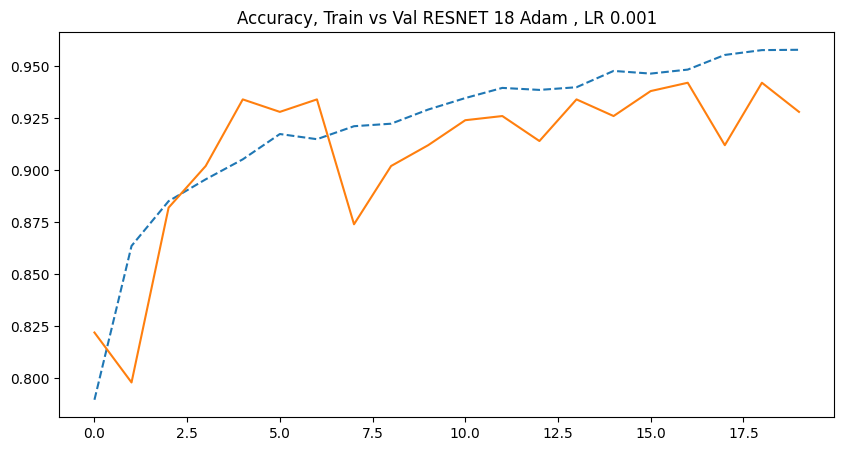

In [8]:
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)
train_acc_list = []
val_acc_list = []

print("TRAINING")
epochs=20
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  train_acc = correct / total
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = correct_val / total_val
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'resnet18_CNN.pth')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val RESNET 18 Adam , LR 0.001")
plt.plot(train_acc_list, label='Train Acc Resnet 18 CNN', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc Resnet 18 CNN', linestyle='-')

In [16]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for name, param in model.named_parameters():
    print(name)

conv1.weight
bn1.weight
bn1.bias
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.weight
layer2.1.bn2.weight
layer2.1.bn2.bias
layer3.0.conv1.weight
layer3.0.bn1.weight
layer3.0.bn1.bias
layer3.0.conv2.weight
layer3.0.bn2.weight
layer3.0.bn2.bias
layer3.0.downsample.0.weight
layer3.0.downsample.1.weight
layer3.0.downsample.1.bias
layer3.1.conv1.weight
layer3.1.bn1.weight
layer3.1.bn1.bias
layer3.1.conv2.weight
layer3.1.bn2.weight
layer3.1.bn2.bias
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.we

TRAINING with Step LR Scheduler 
Train Acc  0.18296
Epoch 1/30, Loss: 2.4642410278320312
Val Acc  0.288
Train Acc  0.29696
Epoch 2/30, Loss: 2.072827100753784
Val Acc  0.326
Train Acc  0.36104
Epoch 3/30, Loss: 1.700068473815918
Val Acc  0.37
Train Acc  0.44936
Epoch 4/30, Loss: 1.4863030910491943
Val Acc  0.504
Train Acc  0.55688
Epoch 5/30, Loss: 1.8342266082763672
Val Acc  0.542
Train Acc  0.64032
Epoch 6/30, Loss: 0.5801786780357361
Val Acc  0.674
Train Acc  0.73112
Epoch 7/30, Loss: 0.9733640551567078
Val Acc  0.774
Train Acc  0.75336
Epoch 8/30, Loss: 0.7554458379745483
Val Acc  0.792
Train Acc  0.76856
Epoch 9/30, Loss: 0.8817179799079895
Val Acc  0.784
Train Acc  0.7756
Epoch 10/30, Loss: 0.3745322823524475
Val Acc  0.816
Train Acc  0.79192
Epoch 11/30, Loss: 0.2473868578672409
Val Acc  0.82
Train Acc  0.80392
Epoch 12/30, Loss: 0.4264778196811676
Val Acc  0.816
Train Acc  0.82184
Epoch 13/30, Loss: 0.8607298731803894
Val Acc  0.862
Train Acc  0.8212
Epoch 14/30, Loss: 0.167455

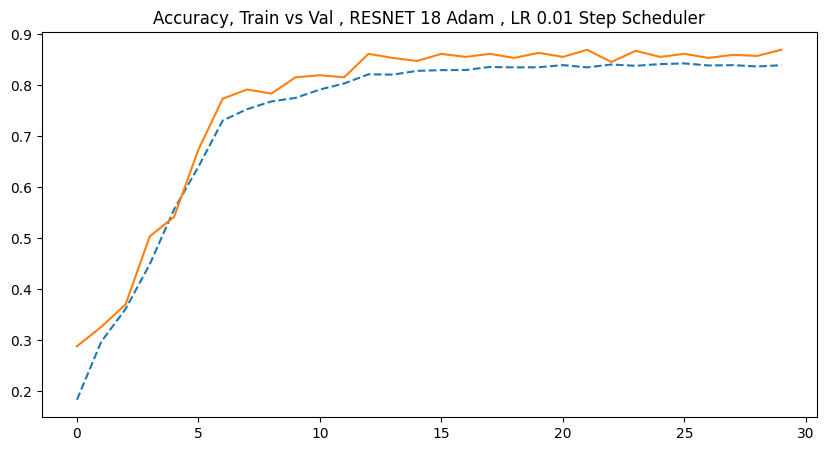

In [18]:
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)
train_acc_list = []
val_acc_list = []

print("TRAINING with Step LR Scheduler ")
epochs=30
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=6, gamma=0.1)
loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  scheduler.step()    
  train_acc = correct / total
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = correct_val / total_val
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'resnet18_CNN_StepScheduler.pth')

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val , RESNET 18 Adam , LR 0.01 Step Scheduler")
plt.plot(train_acc_list, label='Train Acc Resnet 18 CNN Step LR Scheduler', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc Resnet 18 CNN  Step LR Scheduler', linestyle='-')


In [20]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for name, param in model.named_parameters():
    print(name)

conv1.weight
bn1.weight
bn1.bias
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.weight
layer2.1.bn2.weight
layer2.1.bn2.bias
layer3.0.conv1.weight
layer3.0.bn1.weight
layer3.0.bn1.bias
layer3.0.conv2.weight
layer3.0.bn2.weight
layer3.0.bn2.bias
layer3.0.downsample.0.weight
layer3.0.downsample.1.weight
layer3.0.downsample.1.bias
layer3.1.conv1.weight
layer3.1.bn1.weight
layer3.1.bn1.bias
layer3.1.conv2.weight
layer3.1.bn2.weight
layer3.1.bn2.bias
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.we

TRAINING with Cosine LR Scheduler 
Train Acc  0.17808
Epoch 1/30, Loss: 2.165705680847168
Val Acc  0.256
Train Acc  0.24672
Epoch 2/30, Loss: 1.6786752939224243
Val Acc  0.298
Train Acc  0.37288
Epoch 3/30, Loss: 1.6315338611602783
Val Acc  0.444
Train Acc  0.50008
Epoch 4/30, Loss: 1.480583906173706
Val Acc  0.526
Train Acc  0.60176
Epoch 5/30, Loss: 1.0588867664337158
Val Acc  0.622
Train Acc  0.66912
Epoch 6/30, Loss: 1.1202199459075928
Val Acc  0.692
Train Acc  0.70224
Epoch 7/30, Loss: 1.0229742527008057
Val Acc  0.74
Train Acc  0.7384
Epoch 8/30, Loss: 0.722760021686554
Val Acc  0.768
Train Acc  0.76232
Epoch 9/30, Loss: 0.4731716513633728
Val Acc  0.754
Train Acc  0.78568
Epoch 10/30, Loss: 0.5872465372085571
Val Acc  0.8
Train Acc  0.7996
Epoch 11/30, Loss: 0.8255256414413452
Val Acc  0.824
Train Acc  0.8196
Epoch 12/30, Loss: 0.8472496271133423
Val Acc  0.766
Train Acc  0.82664
Epoch 13/30, Loss: 0.33055880665779114
Val Acc  0.818
Train Acc  0.84504
Epoch 14/30, Loss: 0.354351

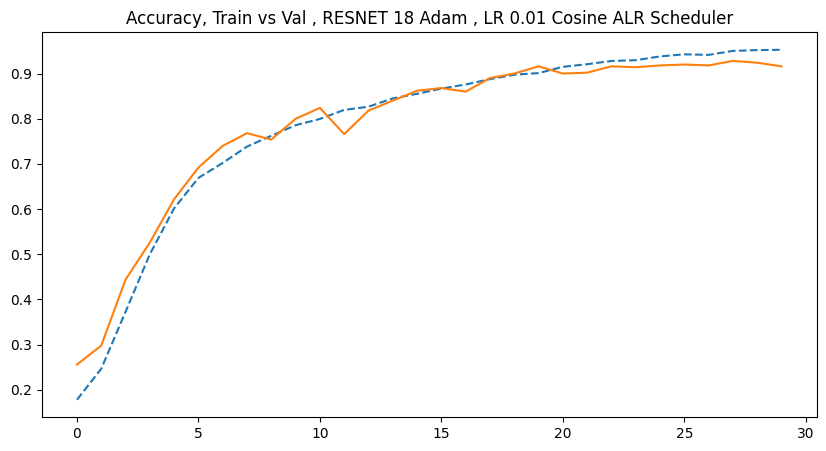

In [21]:
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)
train_acc_list = []
val_acc_list = []

print("TRAINING with Cosine Annealing LR Scheduler ")
epochs=30
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  train_acc = correct / total
  scheduler.step()
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = correct_val / total_val
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'resnet18_CNN_ADAM_CosineALRScheduler.pth')

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val , RESNET 18 Adam , LR 0.01 Cosine ALR Scheduler")
plt.plot(train_acc_list, label='Train Acc Resnet 18 CNN Cosine LR Scheduler', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc Resnet 18 CNN  Cosine LR Scheduler', linestyle='-')


In [22]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for name, param in model.named_parameters():
    print(name)

conv1.weight
bn1.weight
bn1.bias
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.weight
layer2.1.bn2.weight
layer2.1.bn2.bias
layer3.0.conv1.weight
layer3.0.bn1.weight
layer3.0.bn1.bias
layer3.0.conv2.weight
layer3.0.bn2.weight
layer3.0.bn2.bias
layer3.0.downsample.0.weight
layer3.0.downsample.1.weight
layer3.0.downsample.1.bias
layer3.1.conv1.weight
layer3.1.bn1.weight
layer3.1.bn1.bias
layer3.1.conv2.weight
layer3.1.bn2.weight
layer3.1.bn2.bias
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.we

TRAINING with Cosine Annealing LR Scheduler SGD 
Train Acc  0.93808
Epoch 1/20, Loss: 0.12523414194583893
Val Acc  0.974
Train Acc  0.9612
Epoch 2/20, Loss: 0.17737333476543427
Val Acc  0.974
Train Acc  0.96656
Epoch 3/20, Loss: 0.4567190110683441
Val Acc  0.974
Train Acc  0.97336
Epoch 4/20, Loss: 0.015552669763565063
Val Acc  0.982
Train Acc  0.97712
Epoch 5/20, Loss: 0.026100939139723778
Val Acc  0.982
Train Acc  0.9792
Epoch 6/20, Loss: 0.04272431135177612
Val Acc  0.98
Train Acc  0.97904
Epoch 7/20, Loss: 0.11790142208337784
Val Acc  0.982
Train Acc  0.98472
Epoch 8/20, Loss: 0.03881080448627472
Val Acc  0.982
Train Acc  0.98216
Epoch 9/20, Loss: 0.08016986399888992
Val Acc  0.982
Train Acc  0.98688
Epoch 10/20, Loss: 0.010891614481806755
Val Acc  0.984
Train Acc  0.98816
Epoch 11/20, Loss: 0.01805858686566353
Val Acc  0.984
Train Acc  0.98728
Epoch 12/20, Loss: 0.03389212489128113
Val Acc  0.982
Train Acc  0.99024
Epoch 13/20, Loss: 0.018999453634023666
Val Acc  0.982
Train Acc  

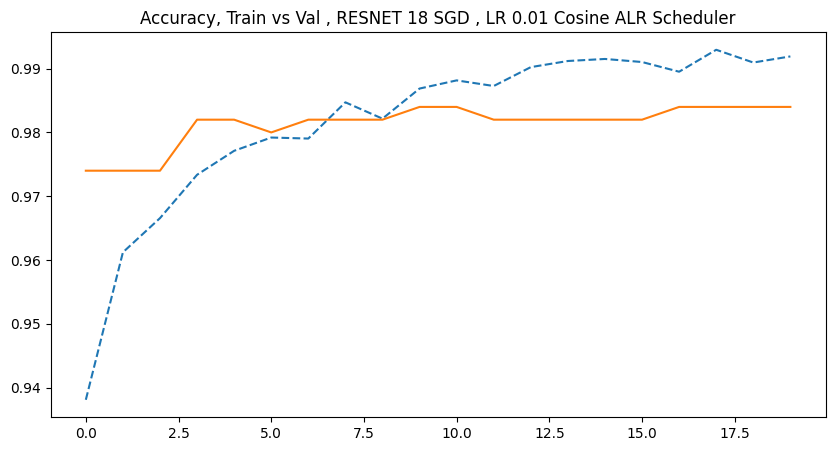

In [25]:
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)
train_acc_list = []
val_acc_list = []

print("TRAINING with Cosine Annealing LR Scheduler SGD ")
epochs=20
optimizer = optim.SGD(model.parameters(), lr=0.01,  weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  train_acc = correct / total
  scheduler.step()  
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = correct_val / total_val
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'resnet18_CNN_SGD_CosineALRScheduler.pth')

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val , RESNET 18 SGD , LR 0.01 Cosine ALR Scheduler")
plt.plot(train_acc_list, label='Train Acc Resnet 18 CNN Cosine LR Scheduler', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc Resnet 18 CNN  Cosine LR Scheduler', linestyle='-')


In [4]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for name, param in model.named_parameters():
    print(name)

conv1.weight
bn1.weight
bn1.bias
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.weight
layer2.1.bn2.weight
layer2.1.bn2.bias
layer3.0.conv1.weight
layer3.0.bn1.weight
layer3.0.bn1.bias
layer3.0.conv2.weight
layer3.0.bn2.weight
layer3.0.bn2.bias
layer3.0.downsample.0.weight
layer3.0.downsample.1.weight
layer3.0.downsample.1.bias
layer3.1.conv1.weight
layer3.1.bn1.weight
layer3.1.bn1.bias
layer3.1.conv2.weight
layer3.1.bn2.weight
layer3.1.bn2.bias
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.we

TRAINING
Train Acc  0.21072
Epoch 1/30, Loss: 1.615520715713501
Val Acc  0.258
Train Acc  0.34488
Epoch 2/30, Loss: 1.6363036632537842
Val Acc  0.346
Train Acc  0.40584
Epoch 3/30, Loss: 1.7504173517227173
Val Acc  0.466
Train Acc  0.46136
Epoch 4/30, Loss: 1.1011922359466553
Val Acc  0.488
Train Acc  0.5168
Epoch 5/30, Loss: 1.2617110013961792
Val Acc  0.534
Train Acc  0.5652
Epoch 6/30, Loss: 1.1189736127853394
Val Acc  0.466
Train Acc  0.60944
Epoch 7/30, Loss: 1.9724184274673462
Val Acc  0.642
Train Acc  0.63736
Epoch 8/30, Loss: 1.0560458898544312
Val Acc  0.662
Train Acc  0.65504
Epoch 9/30, Loss: 0.9239909052848816
Val Acc  0.688
Train Acc  0.67744
Epoch 10/30, Loss: 1.2328473329544067
Val Acc  0.714
Train Acc  0.68976
Epoch 11/30, Loss: 1.5200636386871338
Val Acc  0.658
Train Acc  0.7016
Epoch 12/30, Loss: 0.7826860547065735
Val Acc  0.724
Train Acc  0.71304
Epoch 13/30, Loss: 1.1807467937469482
Val Acc  0.724
Train Acc  0.71848
Epoch 14/30, Loss: 0.862332820892334
Val Acc  0.7

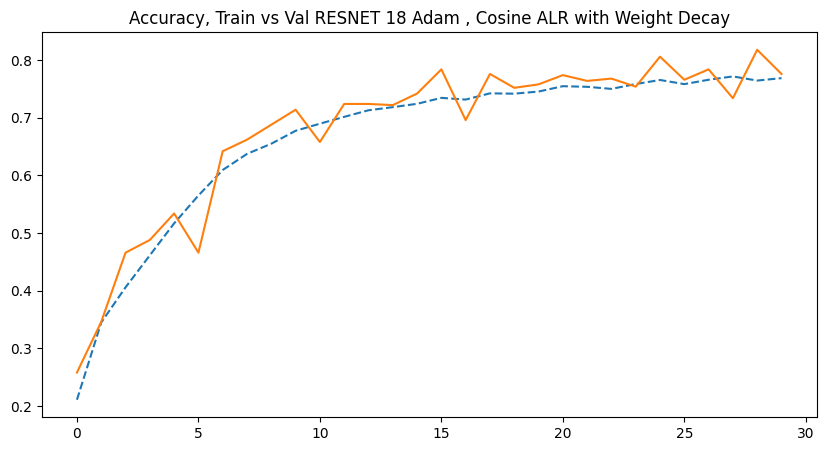

In [5]:
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)
train_acc_list = []
val_acc_list = []

print("TRAINING")
epochs=30
optimizer = optim.Adam(model.parameters(), lr=0.01,  weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  train_acc = correct / total
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = correct_val / total_val
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'resnet18_CNN_ADAM_WeightDecay_CosineALR.pth')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val RESNET 18 Adam , Cosine ALR with Weight Decay")
plt.plot(train_acc_list, label='Train Acc Resnet 18 CNN', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc Resnet 18 CNN', linestyle='-')

In [28]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for name, param in model.named_parameters():
    print(name)

conv1.weight
bn1.weight
bn1.bias
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.weight
layer2.1.bn2.weight
layer2.1.bn2.bias
layer3.0.conv1.weight
layer3.0.bn1.weight
layer3.0.bn1.bias
layer3.0.conv2.weight
layer3.0.bn2.weight
layer3.0.bn2.bias
layer3.0.downsample.0.weight
layer3.0.downsample.1.weight
layer3.0.downsample.1.bias
layer3.1.conv1.weight
layer3.1.bn1.weight
layer3.1.bn1.bias
layer3.1.conv2.weight
layer3.1.bn2.weight
layer3.1.bn2.bias
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.we

TRAINING
Train Acc  0.64848
Epoch 1/20, Loss: 0.8181025385856628
Val Acc  0.904
Train Acc  0.89744
Epoch 2/20, Loss: 0.29215529561042786
Val Acc  0.95
Train Acc  0.92368
Epoch 3/20, Loss: 0.2732730209827423
Val Acc  0.954
Train Acc  0.92688
Epoch 4/20, Loss: 0.4873024821281433
Val Acc  0.96
Train Acc  0.93496
Epoch 5/20, Loss: 0.35866886377334595
Val Acc  0.96
Train Acc  0.93928
Epoch 6/20, Loss: 0.1344304382801056
Val Acc  0.966
Train Acc  0.94208
Epoch 7/20, Loss: 0.19141434133052826
Val Acc  0.968
Train Acc  0.9436
Epoch 8/20, Loss: 0.43737831711769104
Val Acc  0.97
Train Acc  0.94976
Epoch 9/20, Loss: 0.06333502382040024
Val Acc  0.972
Train Acc  0.94976
Epoch 10/20, Loss: 0.12024690955877304
Val Acc  0.97
Train Acc  0.95376
Epoch 11/20, Loss: 0.19653937220573425
Val Acc  0.972
Train Acc  0.95232
Epoch 12/20, Loss: 0.059153735637664795
Val Acc  0.972
Train Acc  0.95504
Epoch 13/20, Loss: 0.21958914399147034
Val Acc  0.968
Train Acc  0.95616
Epoch 14/20, Loss: 0.19337321817874908
Va

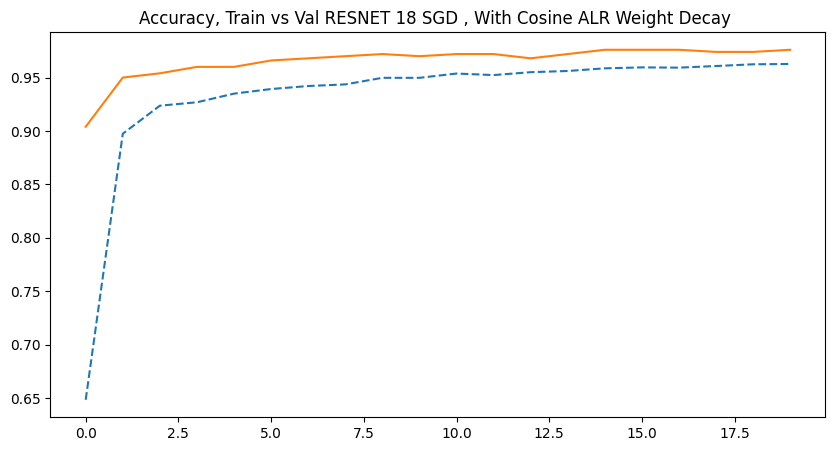

In [30]:
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)
train_acc_list = []
val_acc_list = []

print("TRAINING")
epochs=20
optimizer = optim.SGD(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  train_acc = correct / total
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = correct_val / total_val
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'resnet18_CNN_SGD_CosineALR_WeightDecay.pth')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val RESNET 18 SGD , With Cosine ALR Weight Decay ")
plt.plot(train_acc_list, label='Train Acc Resnet 18 CNN', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc Resnet 18 CNN', linestyle='-')

In [7]:
from torch import optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.models as models
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

# Resizing data to 256 , and random cropping 224X224 improves performance as Resnet and VGG Models are built with that expectation and trained such .
#As this is transfer learning that size and crop works best . 
#Random Horizontal Flip introduced for better training . Normalized data to Imagenet Mean and Standard Deviation
# Batch size 32 for Resnet models are they are faster and less complex and training time is manageable .


imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

validation_transformer = transforms.Compose([
transforms.Resize(256),
transforms.CenterCrop(224),
transforms.ToTensor(),
transforms.Normalize(imagenet_mean, imagenet_std)
])

dataset_test = datasets.ImageFolder("dataset10/val", transform=validation_transformer, allow_empty=True)

dataloader_test = DataLoader(dataset_test, batch_size=32, shuffle=False)
print("Setup Complete")

cuda
Setup Complete


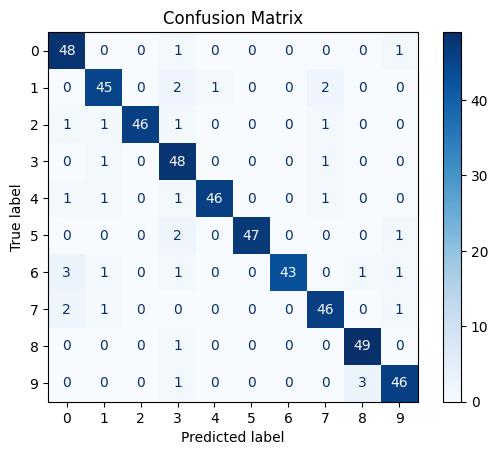

464
500
Test Accuracy: 92.80%
Precision: 0.93
Recall:    0.93
F1 Score:  0.93


In [2]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torchmetrics.classification import AUROC

model = torch.load('resnet18_CNN.pth', weights_only=False)

model.eval()
correct = 0
total = 0
all_labels =[]
all_predictions=[]
with torch.no_grad():
  for images, labels in dataloader_test:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    all_labels.extend(labels.to("cpu").numpy())
    all_predictions.extend(predicted.to("cpu").numpy())
  cm = confusion_matrix(all_labels, all_predictions)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap='Blues')
  plt.title('Confusion Matrix')
  plt.show()
  print(correct)
  print(total)
  print(f"Test Accuracy: {100 * correct / total:.2f}%")
  precision = precision_score(all_labels, all_predictions, average='weighted')
  recall = recall_score(all_labels, all_predictions, average='weighted')
  f1 = f1_score(all_labels, all_predictions, average='weighted')
  print(f"Precision: {precision:.2f}")
  print(f"Recall:    {recall:.2f}")
  print(f"F1 Score:  {f1:.2f}")
 

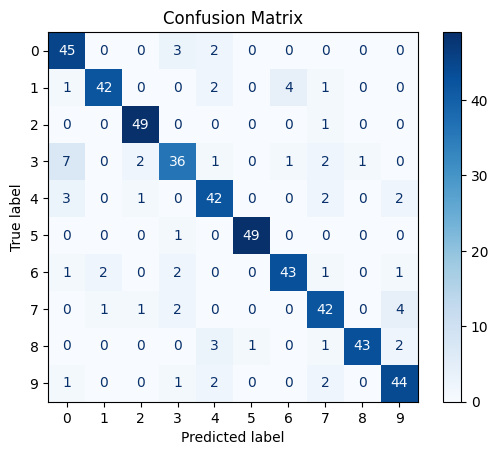

435
500
Test Accuracy: 87.00%
Precision: 0.87
Recall:    0.87
F1 Score:  0.87


In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torchmetrics.classification import AUROC

model = torch.load('resnet18_CNN_StepScheduler.pth', weights_only=False)

model.eval()
correct = 0
total = 0
all_labels =[]
all_predictions=[]
with torch.no_grad():
  for images, labels in dataloader_test:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    all_labels.extend(labels.to("cpu").numpy())
    all_predictions.extend(predicted.to("cpu").numpy())
  cm = confusion_matrix(all_labels, all_predictions)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap='Blues')
  plt.title('Confusion Matrix')
  plt.show()
  print(correct)
  print(total)
  print(f"Test Accuracy: {100 * correct / total:.2f}%")
  precision = precision_score(all_labels, all_predictions, average='weighted')
  recall = recall_score(all_labels, all_predictions, average='weighted')
  f1 = f1_score(all_labels, all_predictions, average='weighted')
  print(f"Precision: {precision:.2f}")
  print(f"Recall:    {recall:.2f}")
  print(f"F1 Score:  {f1:.2f}")
 

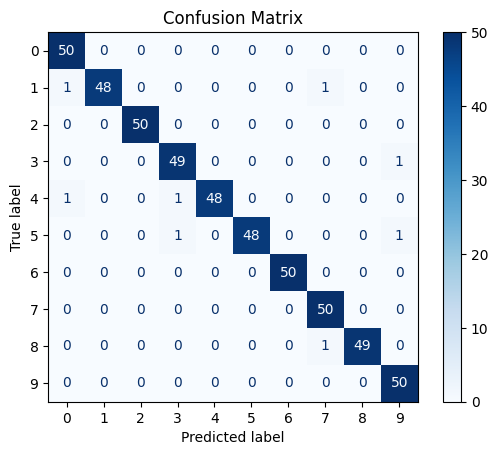

492
500
Test Accuracy: 98.40%
Precision: 0.98
Recall:    0.98
F1 Score:  0.98


In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torchmetrics.classification import AUROC

model = torch.load('resnet18_CNN_SGD_CosineALRScheduler.pth', weights_only=False)

model.eval()
correct = 0
total = 0
all_labels =[]
all_predictions=[]
with torch.no_grad():
  for images, labels in dataloader_test:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    all_labels.extend(labels.to("cpu").numpy())
    all_predictions.extend(predicted.to("cpu").numpy())
  cm = confusion_matrix(all_labels, all_predictions)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap='Blues')
  plt.title('Confusion Matrix')
  plt.show()
  print(correct)
  print(total)
  print(f"Test Accuracy: {100 * correct / total:.2f}%")
  precision = precision_score(all_labels, all_predictions, average='weighted')
  recall = recall_score(all_labels, all_predictions, average='weighted')
  f1 = f1_score(all_labels, all_predictions, average='weighted')
  print(f"Precision: {precision:.2f}")
  print(f"Recall:    {recall:.2f}")
  print(f"F1 Score:  {f1:.2f}")
 

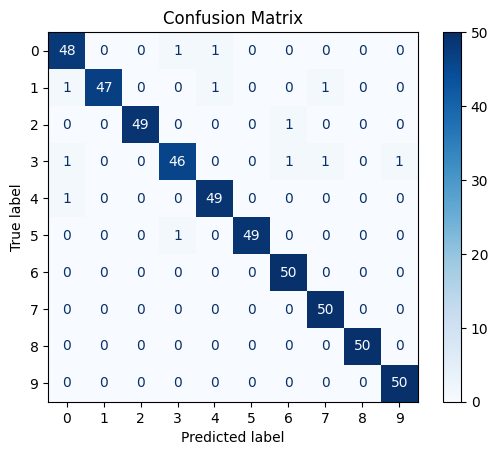

488
500
Test Accuracy: 97.60%
Precision: 0.98
Recall:    0.98
F1 Score:  0.98


In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torchmetrics.classification import AUROC

model = torch.load('resnet18_CNN_SGD_CosineALR_WeightDecay.pth', weights_only=False)

model.eval()
correct = 0
total = 0
all_labels =[]
all_predictions=[]
with torch.no_grad():
  for images, labels in dataloader_test:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    all_labels.extend(labels.to("cpu").numpy())
    all_predictions.extend(predicted.to("cpu").numpy())
  cm = confusion_matrix(all_labels, all_predictions)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap='Blues')
  plt.title('Confusion Matrix')
  plt.show()
  print(correct)
  print(total)
  print(f"Test Accuracy: {100 * correct / total:.2f}%")
  precision = precision_score(all_labels, all_predictions, average='weighted')
  recall = recall_score(all_labels, all_predictions, average='weighted')
  f1 = f1_score(all_labels, all_predictions, average='weighted')
  print(f"Precision: {precision:.2f}")
  print(f"Recall:    {recall:.2f}")
  print(f"F1 Score:  {f1:.2f}")
 

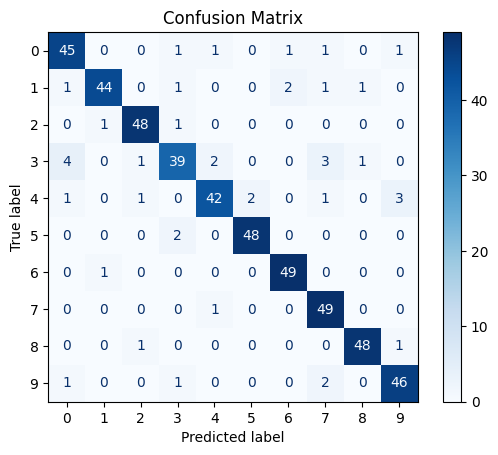

458
500
Test Accuracy: 91.60%
Precision: 0.92
Recall:    0.92
F1 Score:  0.92


In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torchmetrics.classification import AUROC

model = torch.load('resnet18_CNN_ADAM_CosineALRScheduler.pth', weights_only=False)

model.eval()
correct = 0
total = 0
all_labels =[]
all_predictions=[]
with torch.no_grad():
  for images, labels in dataloader_test:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    all_labels.extend(labels.to("cpu").numpy())
    all_predictions.extend(predicted.to("cpu").numpy())
  cm = confusion_matrix(all_labels, all_predictions)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap='Blues')
  plt.title('Confusion Matrix')
  plt.show()
  print(correct)
  print(total)
  print(f"Test Accuracy: {100 * correct / total:.2f}%")
  precision = precision_score(all_labels, all_predictions, average='weighted')
  recall = recall_score(all_labels, all_predictions, average='weighted')
  f1 = f1_score(all_labels, all_predictions, average='weighted')
  print(f"Precision: {precision:.2f}")
  print(f"Recall:    {recall:.2f}")
  print(f"F1 Score:  {f1:.2f}")
 

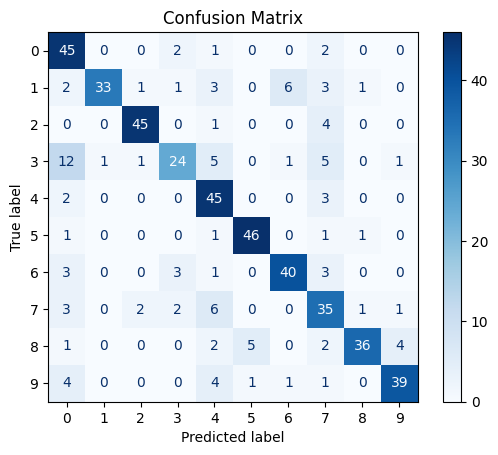

388
500
Test Accuracy: 77.60%
Precision: 0.80
Recall:    0.78
F1 Score:  0.78


In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torchmetrics.classification import AUROC

model = torch.load('resnet18_CNN_ADAM_WeightDecay_CosineALR.pth', weights_only=False)

model.eval()
correct = 0
total = 0
all_labels =[]
all_predictions=[]
with torch.no_grad():
  for images, labels in dataloader_test:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    all_labels.extend(labels.to("cpu").numpy())
    all_predictions.extend(predicted.to("cpu").numpy())
  cm = confusion_matrix(all_labels, all_predictions)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap='Blues')
  plt.title('Confusion Matrix')
  plt.show()
  print(correct)
  print(total)
  print(f"Test Accuracy: {100 * correct / total:.2f}%")
  precision = precision_score(all_labels, all_predictions, average='weighted')
  recall = recall_score(all_labels, all_predictions, average='weighted')
  f1 = f1_score(all_labels, all_predictions, average='weighted')
  print(f"Precision: {precision:.2f}")
  print(f"Recall:    {recall:.2f}")
  print(f"F1 Score:  {f1:.2f}")
 